# App-34 — Complexité de Kolmogorov bornée : résolution de séquences numériques à mémoire limitée

**Positionnement.** Distillation de *Bounded Kolmogorov Complexity Based on Cognitive Models* (Strannegård, Nizamani, Sjöberg et Engström, AGI 2013). Le PDF est archivé dans la bibliographie privée du projet ; il n'est jamais recopié ici. La **méthode** du papier (un langage de termes, une métrique de longueur, un calcul borné par une mémoire de travail) est réimplémentée from scratch en Python, et la batterie d'items est de construction maison — les items du test IST cité par le papier restent sous droits.

**L'idée en une phrase.** La complexité de Kolmogorov K(x) — la longueur du plus court programme qui produit x — est incomputable ; les versions computables (compression, Kt de Levin) ignorent la dimension *cognitive* : elles ne disent rien de ce qu'un agent à mémoire limitée peut *vraiment* trouver. Le mouvement du papier : restreindre les calculs à un modèle cognitif borné, puis chercher le plus court terme qui décrit la séquence **dans ce modèle borné**.

**Ce que ce notebook fait de vérifiable :**

1. un solveur complet de l'espace des termes du papier (énumération par longueur croissante = approfondissement itératif) ;
2. **E1** — balayage de la borne de mémoire B : la prédiction du modèle cognitif est que le score croît (au sens large) puis plateaute avec B — mesuré, pas supposé ;
3. **E2** — paires de séquences appariées dont la structure exige un calcul qui dépasse B : le basculement de réponse doit arriver au seuil prédit par la métrique de longueur ;
4. **E3** — confrontation honnête à deux baselines classiques (interpolation polynomiale, différences finies), verdict par classe d'item.

**Pourquoi ce notebook est falsifiable et pas une démonstration.** Chaque expérience E1-E3 porte une prédiction qui peut échouer : une courbe score(B) non monotone réfuterait la revendication de monotonicité du modèle sur notre batterie ; un basculement E2 qui n'arrive pas au seuil prédit réfuterait la métrique de longueur. Les verdicts sont écrits dans les sorties, y compris négatifs.

## 1. Le problème : pourquoi K ne suffit pas

Une séquence numérique d'un test de type QI est un objet éminemment ambigu. La séquence `1, 2` se continue par 1 (répétition `1,2,1,2`), par 2 (miroir `1,2,2,1`), par 3 (incréments `1,2,3`), par 4 (doublements `1,2,4,8`)… Le « bon » continuant dépend du **sujet** qui regarde — d'où l'idée du papier : modéliser le sujet.

La chaîne de raisonnement :

- K(x) = longueur du plus court programme produisant x : incomputable (problème de l'arrêt), donc inutilisable comme boussole directe ;
- les versions computables (Levin Kt, compression) mesurent une complexité *absolue*, indépendante de l'observateur ;
- un humain résout ces items avec ~7 items en mémoire de travail (Miller) — les patterns qu'il peut trouver sont exactement ceux dont le **calcul tient dans cette fenêtre** ;
- donc : définir K **relativement à un système de réécriture borné**, où la borne modélise la mémoire de travail, et chercher le plus court terme dans ce système borné.

Le papier rapporte que son solveur (Haskell) score 28/38 aux items numériques du test IST — contre 9 pour Mathematica, 9 pour Maple, 12 pour WolframAlpha — et surtout : **passer la mémoire de 8 à 7 items fait baisser le score, passer de 8 à 9 ne le change pas**. C'est cette sensibilité à la borne que E1 réplique sur batterie indépendante.

**Notre batterie n'est pas l'IST** : construite maison, dans l'esprit des items (arithmétiques, géométriques, récurrents, entrelacés, polynomiaux). Toute comparaison chiffrée au 28/38 du papier serait hors de portée — nous comparons le solveur à lui-même à travers la borne B, et à des baselines sur la même batterie.

## 2. Le langage des termes

Les termes décrivent des séquences :

- **numérales** : `0, 1, 2, …` (jusqu'à 99 ici) ;
- **la position** : `n` (index du terme courant, avec décalage possible du point de départ) ;
- **regard en arrière** : `f(n−c)` — la valeur de la séquence c positions plus tôt (c ≤ 3) ;
- **opérations binaires** : `t1 + t2`, `t1 − t2`, `t1 · t2`, `t1 ÷ t2` (division entière, diviseur à un chiffre).

La **longueur d'un terme** (métrique du papier, Def. 3) :

| Terme | Longueur |
|---|---|
| numérale c | nombre de chiffres de c, **zéros traînants ignorés** (`|10| = 1`, `|250| = 2`) |
| `n` | 1 |
| `f(n−c)` | 1 |
| `t1 ⋆ t2` | `|t1| + |t2| + 1` |

Un terme **décrit** la séquence `a0 … a(l−1)` si, en notant b le plus grand regard en arrière du terme : `b < l/2` (les cas de base restent minoritaires — règle du papier) et `t(i) = a_i` pour tout `i ≥ b`. Le terme **prédit** alors `t(l)`.

Exemple du papier : `f(n−2)·f(n−1)` décrit `2, 2, 4, 8, 32` et prédit `256`.

Deux extensions du papier sont incluses dans le solveur : les **descriptions modulo m** (sous-séquences entrelacées — ex. `1, 2, 1, 3, 1, 4, 1, 5`) et les **décalages d'index** (le départ de `n` varie — ex. `1, 4, 9, 16, 25` se décrit par `n·n` si `n` démarre à 1).

In [1]:
# -*- coding: utf-8 -*-
"""Termes du langage et metrique de longueur (papier, Def. 3)."""
from dataclasses import dataclass


@dataclass(frozen=True)
class Num:
    val: int


@dataclass(frozen=True)
class Pos:
    """La position n (le point de depart est decale par le parametre start du solveur)."""


@dataclass(frozen=True)
class Look:
    """f(n-c) : la valeur de la sequence c positions plus tot."""
    back: int


@dataclass(frozen=True)
class Op:
    sym: str  # '+', '-', '*', '//'
    left: object
    right: object


def numeral_len(x: int) -> int:
    """Chiffres de x, zeros trainants ignores (|10|=1, |250|=2, |0|=1)."""
    if x < 0:
        return numeral_len(-x) + 1  # le signe moins compte pour un symbole
    s = str(x).rstrip("0")
    return max(len(s), 1)


def term_len(t):
    if isinstance(t, Num):
        return numeral_len(t.val)
    if isinstance(t, (Pos, Look)):
        return 1
    if isinstance(t, Op):
        return term_len(t.left) + term_len(t.right) + 1
    raise TypeError(t)


def show(t) -> str:
    """Representation lisible d'un terme."""
    if isinstance(t, Num):
        return str(t.val)
    if isinstance(t, Pos):
        return "n"
    if isinstance(t, Look):
        return f"f(n-{t.back})"
    if isinstance(t, Op):
        sym = {"+": "+", "-": "-", "*": ".", "//": ":"}[t.sym]
        return f"({show(t.left)} {sym} {show(t.right)})"
    raise TypeError(t)


# --- controle immediate de la metrique ---
assert numeral_len(10) == 1, "10 = une decennie = un item de memoire"
assert numeral_len(250) == 2
assert term_len(Op("*", Look(2), Look(1))) == 3        # f(n-2).f(n-1)
assert term_len(Op("*", Num(67), Num(89))) == 5        # 67.89
assert term_len(Op("+", Op("-", Look(1), Look(2)), Num(1))) == 5
print("Metrique de longueur : asserts OK")
print(f"|f(n-2).f(n-1)| = {term_len(Op('*', Look(2), Look(1)))}")
print(f"|67.89|          = {term_len(Op('*', Num(67), Num(89)))}")
print(f"|f(n-1).10+1|    = {term_len(Op('+', Op('*', Look(1), Num(10)), Num(1)))}")

Metrique de longueur : asserts OK
|f(n-2).f(n-1)| = 3
|67.89|          = 5
|f(n-1).10+1|    = 5


## 3. Le calcul borné : le modèle de mémoire de travail

C'est le cœur cognitif du papier. Un terme peut être court et pourtant **incomputable pour un agent borné** : le papier cite `67 · 89` — longueur 5, mais aucune de ses réductions ne tient dans une fenêtre de 8 items, parce que le système de réécriture du papier calcule via des **tables arithmétiques 10×10** (opérandes à un chiffre). Un produit à grands opérandes doit d'abord être **décomposé par distributivité**, et les termes intermédiaires décomposés doivent tenir dans la fenêtre.

**Notre opérationnalisation (déclarée).** Le papier utilise un vrai TRS avec tables ; nous le modélisons par une **arithmétique décomposée récursive sous budget** :

- une opération sur numérales à **un chiffre** est un **accès table** — coût `|a| + 1 + |b| ≤ B` ;
- les gestes élémentaires qu'un humain fait sans charger la mémoire — **×10** (appendre un zéro, gratuit au sens de la métrique puisque les zéros traînants ne comptent pas) et **±1 sur unité** — sont à coût réduit ;
- sinon, le plus grand opérande est décomposé (`x = 10·h + u`), et le **terme décomposé** — par exemple `a·h·10 + a·u` pour le produit — doit tenir dans la fenêtre **B** avant que la récursion continue sur ses sous-calculs ;
- toute valeur intermédiaire de la chaîne doit satisfaire le budget.

Cette opérationnalisation est plus simple que le TRS du papier (elle n'a pas sa bibliothèque de règles algébriques complète) mais elle en capture la propriété décisive : **un calcul n'est borné que si toutes ses étapes intermédiaires tiennent dans B**. C'est exactement la propriété dont E2 a besoin pour être falsifiable.

In [2]:
# -*- coding: utf-8 -*-
"""Arithmetique bornee : decomposition recursive sous budget de longueur.

Operationnalisation du TRS a tables du papier (section 3.2) :
- tables 10x10  -> operandes a un chiffre, cout |a|+1+|b| <= B ;
- x10, +1, -1   -> gestes elementaires a cout reduit ;
- sinon         -> distributivite sur le grand operande, le terme decompose
                   doit tenir dans B avant recursion.
"""
B_DEF = 8


def _dec(x: int):
    """x = 10*h + u avec u chiffre."""
    return divmod(x, 10)


def bounded_mul(a: int, b: int, B: int) -> bool:
    """a*b calculable avec toutes les etapes <= B items ?"""
    if a < 0 or b < 0:
        return bounded_mul(abs(a), abs(b), B)
    big, small = (a, b) if a >= b else (b, a)
    if small in (0, 1):
        return True
    if small == 10:
        # appendre un zero : la metrique ignore les zeros trainants
        return numeral_len(big) <= B
    if numeral_len(small) == 1 and numeral_len(big) == 1:
        return 3 <= B  # acces table
    h, u = _dec(big)
    # terme intermediaire apres factorisation : (small.h).10 + small.u
    cost = (numeral_len(small) + 1 + numeral_len(h)
            + 1 + numeral_len(small) + 1 + numeral_len(u))
    if cost > B:
        return False
    return bounded_mul(small * h, 10, B) and bounded_mul(small, u, B)


def bounded_add(a: int, b: int, B: int) -> bool:
    """a+b borne : tables si un chiffre, gestes elementaires, sinon decomposition."""
    if a < 0 and b < 0:
        # -a + -b = -(a + b)
        return bounded_add(-a, -b, B) and numeral_len(a + b) + 1 <= B
    if b < 0:
        return bounded_sub(a, -b, B)
    if a < 0:
        return bounded_sub(b, -a, B)  # b + (-|a|) = b - |a|
    if numeral_len(a) == 1 and numeral_len(b) == 1:
        return 3 <= B
    big, small = (a, b) if a >= b else (b, a)
    if small in (0, 1):
        return numeral_len(big) + 2 <= B
    h, u = _dec(big)
    # (h.10 + u) + small = (h + small).10 + u apres re-arrangement
    cost = (numeral_len(h) + 1 + numeral_len(small) + 1 + numeral_len(u)) + 1
    if cost > B:
        return False
    return bounded_add(h, small, B) and bounded_add(u, 0, B)


def bounded_sub(a: int, b: int, B: int) -> bool:
    """a-b borne."""
    if b < 0:
        return bounded_add(a, -b, B)
    if a < 0:
        # -|a| - b = -(|a| + b)
        return bounded_add(-a, b, B) and numeral_len(a - b) + 1 <= B
    if numeral_len(a) == 1 and numeral_len(b) == 1:
        return 3 <= B
    if b == 0:
        return True
    big, small = (a, b) if a >= b else (b, a)
    if small in (0, 1):
        return numeral_len(big) + 2 <= B
    h, u = _dec(big)
    cost = (numeral_len(h) + 1 + numeral_len(small) + 1 + numeral_len(u)) + 1
    if cost > B:
        return False
    return bounded_sub(h, small, B) and bounded_sub(u, 0, B)


def bounded_div(a: int, b: int, B: int) -> bool:
    """Division entiere : diviseur a un chiffre (colonne de table), dividende decompose."""
    if b == 0:
        return False
    if a < 0 or b < 0:
        return bounded_div(abs(a), abs(b), B)
    if numeral_len(b) > 1:
        return False
    if numeral_len(a) == 1:
        return 3 <= B
    h, u = _dec(a)
    cost = numeral_len(h) + 1 + 1 + 1 + numeral_len(u)
    if cost > B:
        return False
    return bounded_div(h, b, B) and bounded_div(u, b, B)


BOUNDED_OPS = {"+": bounded_add, "-": bounded_sub, "*": bounded_mul, "//": bounded_div}


def apply_op(sym: str, a: int, b: int):
    if sym == "+":
        return a + b
    if sym == "-":
        return a - b
    if sym == "*":
        return a * b
    if sym == "//":
        return abs(a) // abs(b) if (a < 0) == (b < 0) else -(abs(a) // abs(b))
    raise ValueError(sym)


# --- controles : les exemples du papier ---
print("8 * 32   borne a B=8 :", bounded_mul(8, 32, B_DEF))    # le papier : oui
print("67 * 89  borne a B=8 :", bounded_mul(67, 89, B_DEF))   # le papier : NON
print("67 * 89  borne a B=12 :", bounded_mul(67, 89, 12))
print("1111 * 10 borne a B=8 :", bounded_mul(1111, 10, B_DEF), "(geste elementaire)")
print("48 * 3   borne a B=6 :", bounded_mul(48, 3, 6), "/ a B=7 :", bounded_mul(48, 3, 7))

8 * 32   borne a B=8 : True
67 * 89  borne a B=8 : False
67 * 89  borne a B=12 : True
1111 * 10 borne a B=8 : True (geste elementaire)
48 * 3   borne a B=6 : False / a B=7 : True


In [3]:
# -*- coding: utf-8 -*-
"""Evaluation d'un terme sur une sequence, avec verification de bornitude."""


def eval_term(t, seq, i, B, start=0):
    """Valeur de t(i) sur seq, ou None si une etape depasse la borne B.

    start : decalage du point de depart de n (papier, section 3.4).
    """
    if isinstance(t, Num):
        return t.val
    if isinstance(t, Pos):
        return i + start
    if isinstance(t, Look):
        j = i - t.back
        if 0 <= j < len(seq):
            return seq[j]
        return None
    if isinstance(t, Op):
        a = eval_term(t.left, seq, i, B, start)
        b = eval_term(t.right, seq, i, B, start)
        if a is None or b is None:
            return None
        if not BOUNDED_OPS[t.sym](a, b, B):
            return None
        v = apply_op(t.sym, a, b)
        if numeral_len(v) > B:  # le resultat lui-meme doit tenir en memoire
            return None
        return v
    raise TypeError(t)


# --- exemples travailles du papier ---
seq_mul = [2, 2, 4, 8, 32]
t_mul = Op("*", Look(2), Look(1))
vals = [eval_term(t_mul, seq_mul, i, B_DEF) for i in range(2, 5)]
print("terme f(n-2).f(n-1) sur 2,2,4,8,32 :")
print("  valeurs calculees aux positions 2..4 :", vals, "(attendu [4, 8, 32])")
pred = eval_term(t_mul, seq_mul + [32 * 8], 5, B_DEF)  # position 5 : f(3)*f(4) = 8*32
print("  prediction en position 5 :", pred, "(attendu 256)")

seq_fib = [2, 3, 5, 8, 13, 21]
t_add = Op("+", Look(1), Look(2))
vals2 = [eval_term(t_add, seq_fib, i, B_DEF) for i in range(2, 6)]
print("terme f(n-1)+f(n-2) sur 2,3,5,8,13,21 :")
print("  valeurs :", vals2, "(attendu [5, 8, 13, 21])")

# la borne agit : un terme court peut devenir incomputable sur de grandes valeurs
print("grands produits : 256*2048 borne a B=12 :", bounded_mul(256, 2048, 12),
      "/ a B=14 :", bounded_mul(256, 2048, 14))

terme f(n-2).f(n-1) sur 2,2,4,8,32 :
  valeurs calculees aux positions 2..4 : [4, 8, 32] (attendu [4, 8, 32])
  prediction en position 5 : 256 (attendu 256)
terme f(n-1)+f(n-2) sur 2,3,5,8,13,21 :
  valeurs : [5, 8, 13, 21] (attendu [5, 8, 13, 21])
grands produits : 256*2048 borne a B=12 : False / a B=14 : True


## 4. Le solveur : énumération par longueur croissante

La recherche du terme le plus court est un **approfondissement itératif** sur l'espace des termes : pour L = 1, 2, 3, … on énumère tous les termes de longueur exactement L, on garde ceux qui **décrivent** la séquence (avec calculs bornés), et on s'arrête au premier L qui fournit un candidat. Les candidats de même L sont départagés par l'**ordre de préférence** du papier :

1. termes plus courts d'abord (rasoir d'Occam) ;
2. description complète > description modulo 2 > modulo 3 ;
3. termes sans `n` nu (les valeurs passées sont plus basiques que les positions) ;
4. plus petite valeur prédite.

Le budget de recherche du notebook est **déclaré** : numérales jusqu'à 99, regards en arrière jusqu'à 3, longueur maximale 5 par défaut (la longueur 7, coûteuse, reste disponible en démo ponctuelle). Les cubes `n·n·n` (longueur 7) sont donc hors budget ici — c'est une limite de la démonstration, pas du langage.

In [4]:
# -*- coding: utf-8 -*-
"""Enumeration des termes par longueur exacte + solveur complet."""
from functools import lru_cache

NUMERALS = list(range(0, 100))  # numerales a au plus 2 chiffres


@lru_cache(maxsize=None)
def terms_of_len(L: int):
    """Termes de longueur exactement L, avec metadonnees precalculees.

    Renvoie un tuple de (terme, lookback_max, contient_n_nu) -- le filtrage
    par lookback se fait sans recursion au moment du solve.
    """
    if L == 1:
        out = [(Pos(), 0, True), (Look(1), 1, False), (Look(2), 2, False), (Look(3), 3, False)]
        out += [(Num(c), 0, False) for c in NUMERALS if numeral_len(c) == 1]
        return tuple(out)
    if L == 2:
        return tuple((Num(c), 0, False) for c in NUMERALS if numeral_len(c) == 2)
    out = []
    for sym in ("+", "-", "*", "//"):
        commutative = sym in ("+", "*")
        for Ll in range(1, L - 1):
            Lr = L - 1 - Ll
            for left, bl, nl in terms_of_len(Ll):
                for right, br, nr in terms_of_len(Lr):
                    if commutative and (Ll > Lr or (Ll == Lr and show(left) > show(right))):
                        continue  # canonisation des operations commutatives
                    out.append((Op(sym, left, right), max(bl, br), nl or nr))
    return tuple(out)


def describes(t, look, seq, B, mod=1, start=0):
    """t decrit-il seq (ou sa sous-sequence de residue len%mod) avec calculs bornes ?

    Renvoie la valeur predite si oui, None sinon. Regle du papier : look < l/2.
    La sous-sequence mod m retenue est celle dont la prochaine position est
    la reponse (residu len(seq) % m).
    """
    l = len(seq)
    if look * 2 >= l:
        return None
    residue = l % mod
    idxs = [i for i in range(look, l) if mod == 1 or i % mod == residue]
    if len(idxs) < (2 if mod > 1 else 1):
        return None
    for i in idxs:
        v = eval_term(t, seq, i, B, start)
        if v is None or v != seq[i]:
            return None
    nxt = idxs[-1] + mod
    return eval_term(t, seq, nxt, B, start)


def solve(seq, B=B_DEF, Lmax=5, allow_mod=True, start_range=range(-9, 10)):
    """Renvoie (terme, prediction, longueur, mod, start) ou None.

    Ordre de preference du papier : longueur ; complet > modulo ; sans n nu ;
    petite prediction.
    """
    for L in range(1, Lmax + 1):
        found = []
        have_complete = False
        for t, look, bare in terms_of_len(L):
            if look * 2 >= len(seq):
                continue
            for start in start_range:
                if start != 0 and not bare:
                    continue  # sans n nu, le decalage ne change rien
                mods = (1, 2, 3) if allow_mod else (1,)
                for mod in mods:
                    if mod > 1 and (len(seq) < 2 * mod + 1 or have_complete):
                        continue
                    v = describes(t, look, seq, B, mod=mod, start=start)
                    if v is not None:
                        found.append((mod, bare, v, t, start))
                        if mod == 1:
                            have_complete = True
        if found:
            found.sort(key=lambda x: (x[0], x[1], x[2]))
            mod, bare, v, t, start = found[0]
            return t, v, L, mod, start
    return None

In [5]:
# -*- coding: utf-8 -*-
"""Demonstrations du solveur sur les exemples travailles."""
import time

t0 = time.time()
tests = [
    ([2, 2, 4, 8, 32], 256, "recurrence multiplicative (exemple du papier)"),
    ([2, 3, 5, 8, 13, 21], 34, "Fibonacci decale"),
    ([1, 2, 1, 3, 1, 4, 1, 5], 1, "entrelace mod 2"),
    ([1, 4, 9, 16, 25], 36, "carres (decalage d'index n=1..)"),
    ([4, 9, 16, 25, 36], 49, "carres decales (n=2..)"),
    ([4, 7, 12, 20, 33], 54, "recurrence additive + constante"),
    ([1, 11, 111, 1111], 11111, "appendre un 1 : geste elementaire x10"),
]
for seq, expected, label in tests:
    r = solve(seq)
    if r is None:
        print(f"{seq!s:28} -> ECHEC ({label})")
    else:
        t, v, L, mod, start = r
        ok = "OK" if v == expected else f"attendu {expected}"
        print(f"{seq!s:28} -> {v:6} par {show(t):22} L={L} mod={mod} start={start:+d} [{ok}] ({label})")
print(f"duree : {time.time() - t0:.1f}s")

[2, 2, 4, 8, 32]             ->    256 par (f(n-1) . f(n-2))      L=3 mod=1 start=+0 [OK] (recurrence multiplicative (exemple du papier))


[2, 3, 5, 8, 13, 21]         ->     34 par (f(n-1) + f(n-2))      L=3 mod=1 start=+0 [OK] (Fibonacci decale)
[1, 2, 1, 3, 1, 4, 1, 5]     ->      1 par f(n-2)                 L=1 mod=2 start=+0 [OK] (entrelace mod 2)
[1, 4, 9, 16, 25]            ->     36 par (n . n)                L=3 mod=1 start=+1 [OK] (carres (decalage d'index n=1..))


[4, 9, 16, 25, 36]           ->     49 par (n . n)                L=3 mod=1 start=+2 [OK] (carres decales (n=2..))


[4, 7, 12, 20, 33]           ->     54 par (f(n-1) + (1 + f(n-2))) L=5 mod=1 start=+0 [OK] (recurrence additive + constante)


[1, 11, 111, 1111]           ->  11111 par (1 + (10 . f(n-1)))    L=5 mod=1 start=+0 [OK] (appendre un 1 : geste elementaire x10)
duree : 17.9s


## 5. E1 — le balayage de la borne de mémoire

**Prédiction falsifiable.** Le modèle cognitif du papier revendique que la borne B joue le rôle d'une mémoire de travail : réduire B doit **dégrader** le solveur (des patterns deviennent incomputables), l'augmenter ne doit plus rien changer passé un plateau (les items de la batterie n'exigent pas plus). Formellement : score(B) croît au sens large, puis plateaute. **Réfutation** : une courbe non monotone, ou sans plateau sur la plage testée.

La batterie est **maison** : 30 items, 6 classes, réponse attendue unique, tous solubles par un terme de longueur ≤ 5 dans le langage (les items exigeant L=7 comme les cubes sont exclus du protocole et documentés en limite).

**Un miss structurel attendu, à lire comme un comportement du modèle.** L'item `2, 3, 5, 9, 17 → 33` (`f(n−1)·2−1`, longueur 5) est systématiquement loupé : la sous-séquence impaire `3, 9` se décrit plus court — `3·n` modulo 2, longueur 3 — et l'ordre de préférence du papier met la **longueur avant la complétude**. Le solveur répond 15 à toute borne. Ce n'est pas un défaut de l'implémentation : c'est la hiérarchie de préférence du modèle qui s'exprime, et le plateau de la courbe E1 en garde la trace (29/30, pas 30/30).

In [6]:
# -*- coding: utf-8 -*-
"""Batterie maison : 30 items, 6 classes, reponse attendue unique."""
# (sequence, attendu, classe)
BATTERY = [
    # arithmetiques (f(n-1)+k)
    ([3, 7, 11, 15, 19], 23, "arith"),
    ([12, 9, 6, 3], 0, "arith"),
    ([5, 14, 23, 32], 41, "arith"),
    ([100, 93, 86, 79], 72, "arith"),
    ([7, 7, 9, 9, 11, 11], 13, "arith"),
    # geometriques (f(n-1).k)
    ([3, 6, 12, 24, 48], 96, "geo"),
    ([2, 6, 18, 54], 162, "geo"),
    ([1, 4, 16, 64], 256, "geo"),
    ([5, 10, 20, 40, 80], 160, "geo"),
    ([4, 12, 36, 108], 324, "geo"),
    # recurrents d'ordre 2
    ([1, 1, 2, 3, 5, 8], 13, "recc"),
    ([2, 2, 4, 8, 32], 256, "recc"),
    ([1, 2, 5, 12, 29], 70, "recc"),
    ([4, 6, 10, 16, 26, 42], 68, "recc"),
    ([3, 5, 8, 13, 21], 34, "recc"),
    # entrelaces (mod 2)
    ([1, 10, 2, 20, 3, 30, 4], 40, "mod2"),
    ([2, 1, 4, 2, 6, 3, 8], 4, "mod2"),
    ([5, 100, 10, 200, 15, 300], 20, "mod2"),
    ([9, 1, 8, 2, 7, 3, 6], 4, "mod2"),
    ([1, 2, 1, 3, 1, 4, 1, 5], 1, "mod2"),
    # polynomiaux (n.n etc., avec decalage)
    ([1, 4, 9, 16, 25], 36, "poly"),
    ([0, 1, 4, 9, 16], 25, "poly"),
    ([4, 9, 16, 25, 36], 49, "poly"),
    ([2, 6, 12, 20, 30], 42, "poly"),
    ([0, 2, 6, 12, 20], 30, "poly"),
    # mixtes / interessants
    ([1, 2, 6, 24, 120], 720, "mixte"),      # factorielles : f(n-1).n
    ([2, 3, 5, 9, 17], 33, "mixte"),          # f(n-1).2-1
    ([10, 5, 9, 4, 8, 3], 7, "mixte"),        # deux soustractions entrelacees
    ([1, 11, 111, 1111], 11111, "mixte"),     # f(n-1).10+1
    ([6, 36, 216, 1296], 7776, "mixte"),      # geometrique a grands produits
]
assert len(BATTERY) == 30
classes = sorted({c for _, _, c in BATTERY})
print(f"Batterie : {len(BATTERY)} items, classes : {', '.join(classes)}")

Batterie : 30 items, classes : arith, geo, mixte, mod2, poly, recc


In [7]:
# -*- coding: utf-8 -*-
"""E1 : balayage de B sur la batterie complete."""
import time

def battery_score(B, Lmax=5):
    ok, fails = 0, []
    for seq, expected, cls in BATTERY:
        r = solve(seq, B=B, Lmax=Lmax, start_range=range(0, 4))
        if r is not None and r[1] == expected:
            ok += 1
        else:
            fails.append((cls, tuple(seq), expected, r[1] if r else None))
    return ok, fails

t0 = time.time()
B_VALUES = [4, 6, 8, 10, 12]
sweep = {}
fails_by_B = {}
for B in B_VALUES:
    ok, fails = battery_score(B)
    sweep[B] = ok
    fails_by_B[B] = fails
    print(f"B={B:2d} : {ok}/{len(BATTERY)}")
print(f"duree totale : {time.time() - t0:.1f}s")
print()
print("items manques a B=8 (classe, sequence, attendu, obtenu) :")
for f in fails_by_B[8]:
    print("  ", f)

B= 4 : 16/30


B= 6 : 20/30


B= 8 : 28/30


B=10 : 29/30


B=12 : 29/30
duree totale : 153.5s

items manques a B=8 (classe, sequence, attendu, obtenu) :
   ('mixte', (2, 3, 5, 9, 17), 33, 15)
   ('mixte', (6, 36, 216, 1296), 7776, None)


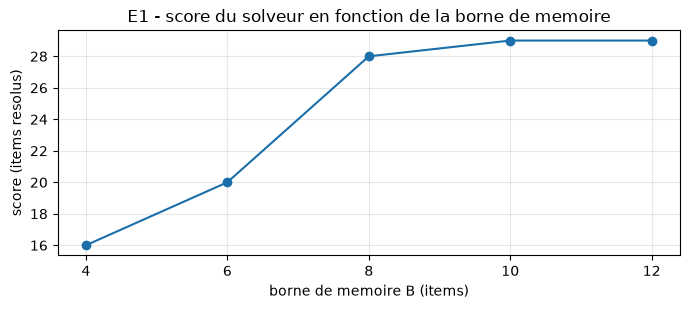

non-monotonies : aucune
plateau depuis B = 10
Verdict E1 : CORROBORE


In [8]:
# -*- coding: utf-8 -*-
"""E1 : verdict de monotonie et de plateau."""
import matplotlib.pyplot as plt

Bs = sorted(sweep)
scores = [sweep[b] for b in Bs]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(Bs, scores, "o-", color="#1a6faa")
ax.set_xlabel("borne de memoire B (items)")
ax.set_ylabel("score (items resolus)")
ax.set_title("E1 - score du solveur en fonction de la borne de memoire")
ax.set_xticks(Bs)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

nonmono = [(Bs[i], scores[i], scores[i + 1])
           for i in range(len(Bs) - 1) if scores[i + 1] < scores[i]]
plateau_from = None
for i in range(len(Bs)):
    if all(scores[j] == scores[i] for j in range(i, len(Bs))):
        plateau_from = Bs[i]
        break
print("non-monotonies :", nonmono if nonmono else "aucune")
print("plateau depuis B =", plateau_from)
verdict_e1 = ("CORROBORE" if not nonmono and plateau_from is not None
              else "REFUTE" if nonmono else "PLATEAU NON ATTEINT")
print(f"Verdict E1 : {verdict_e1}")
if nonmono:
    print("  -> la prediction monotone du modele cognitif est REFUTEE sur cette batterie")

## 6. E2 — la discrimination à la borne

**Prédiction falsifiable.** Si la métrique de longueur et le modèle borné décrivent correctement *ce qui tient en mémoire*, alors le seuil de basculement d'une suite géométrique `f(n−1)·k` doit être **exactement** le plus petit B auquel le dernier produit de la chaîne (celui de la prédiction) devient borné — calculable indépendamment par `bounded_mul`, pas ajusté après coup. Une mesure qui bascule avant ou après son seuil prédit réfute l'opérationnalisation.

**Contrôle de l'expérience** : la recherche est figée sur la classe des descriptions directes (longueur ≤ 4 — la forme `f(n−1)·k`, son jumeau par regard arrière `f(n−2)·k²` quand k² ≤ 99, le double `f(n−1)+f(n−1)`), pour isoler l'effet de la **borne** de l'ingéniosité de la recherche complète. Le seuil prédit est le minimum de ces routes, chacune sondée indépendamment par `bounded_mul`/`bounded_add` — pas ajusté après coup. En longueur ≤ 5, le solveur trouve en effet des routes alternatives plus économiques — par exemple les doubles `2, 4, 8, 16, 32` se calculent dès B=5 par `8 · (f(n−2) ÷ 2)` : c'est la richesse du langage, mesurée par E1/E3, pas ce que E2 veut tester.

In [9]:
# -*- coding: utf-8 -*-
"""E2 : paires appariees et courbe de basculement (classe de descriptions fixee L<=4)."""

def geo_seq(k, first=2, n_terms=5):
    seq = [first]
    for _ in range(n_terms - 1):
        seq.append(seq[-1] * k)
    return seq, seq[-1] * k


def first_bounded(f, Bmax=15):
    """Plus petit B auquel f(B) devient vrai, ou None."""
    for B in range(3, Bmax + 1):
        if f(B):
            return B
    return None


def predicted_threshold(k, first=2, n_terms=5):
    """Min sur les routes directes du seuil de bornitude du produit de prediction."""
    seq, expected = geo_seq(k, first, n_terms)
    routes = [lambda B: bounded_mul(seq[-1], k, B)]
    if k * k <= 99:
        routes.append(lambda B: bounded_mul(seq[-2], k * k, B))
    if k == 2:
        routes.append(lambda B: bounded_add(seq[-1], seq[-1], B))
    thrs = [t for t in (first_bounded(f) for f in routes) if t is not None]
    return min(thrs) if thrs else None


pairs = [(2, "produits petits"), (3, "produits petits"), (7, "produits moyens"),
         (17, "grands produits"), (23, "grands produits")]
print(f"{'k':>3} {'attendu':>8} {'seuil predit':>12} {'bascule mesuree':>15}  verdict")
all_match = True
for k, label in pairs:
    seq, expected = geo_seq(k)
    thr = predicted_threshold(k)
    measured = None
    for B in range(3, 16):
        r = solve(seq, B=B, Lmax=4, allow_mod=False, start_range=(0,))
        if r is not None and r[1] == expected:
            measured = B
            break
    match = (measured == thr)
    all_match = all_match and match
    print(f"{k:>3} {expected:>8} {str(thr):>12} {str(measured):>15}  "
          f"{'MATCH' if match else 'ECART'}  ({label})")
print()
print("Verdict E2 :", "CORROBORE" if all_match else "REFUTE (au moins un ecart seuil/mesure)")

  k  attendu seuil predit bascule mesuree  verdict


  2       64            7               7  MATCH  (produits petits)


  3      486            7               7  MATCH  (produits petits)


  7    33614            8               8  MATCH  (produits moyens)


 17  2839714           13              13  MATCH  (grands produits)


 23 12872686           13              13  MATCH  (grands produits)

Verdict E2 : CORROBORE


## 7. E3 — baselines honnêtes

Deux baselines classiques, sur la même batterie :

- **interpolation polynomiale** : le polynôme de degré l−1 passant par les l points, évalué en l (Lagrange, arithmétique exacte via `fractions`) ;
- **différences finies** : si le tableau des différences devient constant à profondeur d, extrapoler.

L'interpolation polynomiale « résout » tout item par construction — mais avec le **mauvais terme** dès que la séquence n'est pas polynomiale : c'est le contre-exemple vivant de la thèse du papier (le plus court programme n'est pas le plus court *polynôme*). Le verdict se lit par classe.

In [10]:
# -*- coding: utf-8 -*-
"""E3 : baselines sur la meme batterie, verdict par classe."""
from fractions import Fraction
from collections import defaultdict


def poly_next(seq):
    """Interpolation de Lagrange sur les l points x=0..l-1, evaluee en x=l."""
    l = len(seq)
    total = Fraction(0)
    for j in range(l):
        term = Fraction(seq[j])
        for m in range(l):
            if m != j:
                term *= Fraction(l - m, j - m)
        total += term
    return int(total) if total.denominator == 1 else None


def diff_next(seq):
    """Extrapolation par differences finies si une ligne devient constante."""
    rows = [list(seq)]
    while len(rows[-1]) > 1:
        cur = rows[-1]
        nxt = [cur[i + 1] - cur[i] for i in range(len(cur) - 1)]
        rows.append(nxt)
        if len(set(nxt)) == 1:
            v = nxt[0]
            for row in reversed(rows[:-1]):
                v = row[-1] + v
            return v
    return None


def run_on_battery(fn):
    per_class = defaultdict(lambda: [0, 0])
    for seq, expected, cls in BATTERY:
        got = fn(seq)
        good = got is not None and got == expected
        per_class[cls][0 if good else 1] += 1
    total_ok = sum(v[0] for v in per_class.values())
    return total_ok, dict(per_class)


ok_solver, pc_solver = run_on_battery(
    lambda s: (lambda r: r[1] if r else None)(solve(s, start_range=range(0, 4))))
ok_poly, pc_poly = run_on_battery(poly_next)
ok_diff, pc_diff = run_on_battery(diff_next)

print(f"solver K borne (B=8) : {ok_solver}/{len(BATTERY)}")
print(f"interpolation poly   : {ok_poly}/{len(BATTERY)}")
print(f"differences finies   : {ok_diff}/{len(BATTERY)}")
print()
print(f"{'classe':8} {'K borne':>9} {'poly':>6} {'diff':>6}")
for cls in ["arith", "geo", "recc", "mod2", "poly", "mixte"]:
    n = sum(pc_solver.get(cls, [0, 0]))
    if n == 0:
        continue
    s, p, d = pc_solver.get(cls, [0, 0]), pc_poly.get(cls, [0, 0]), pc_diff.get(cls, [0, 0])
    print(f"{cls:8} {s[0]:>4}/{n:<4} {p[0]:>3}/{n:<3} {d[0]:>3}/{n:<3}")
print()
print("Lecture attendue : le solveur borne domine sur recc/mod2/mixte ;")
print("l'interpolation ne domine que sur poly -- en payant des reponses")
print("fausses partout ailleurs (elle repond toujours, juste souvent a cote).")

solver K borne (B=8) : 28/30
interpolation poly   : 9/30
differences finies   : 9/30

classe     K borne   poly   diff
arith       5/5      4/5     4/5  
geo         5/5      0/5     0/5  
recc        5/5      0/5     0/5  
mod2        5/5      0/5     0/5  
poly        5/5      5/5     5/5  
mixte       3/5      0/5     0/5  

Lecture attendue : le solveur borne domine sur recc/mod2/mixte ;
l'interpolation ne domine que sur poly -- en payant des reponses
fausses partout ailleurs (elle repond toujours, juste souvent a cote).


## 8. Exercices

Trois exercices, stubs corrects (aucune erreur volontaire — le notebook s'exécute de bout en bout). Complétez, re-exécutez, et comparez aux attestations attendues affichées.

In [11]:
# -*- coding: utf-8 -*-
"""Exercice 1 -- metrique de longueur et plafond de description.

Le papier impose b < l/2 (cas de base minoritaires). Ecrivez
max_usable_lookback(l) : le plus grand regard en arriere ADMISSIBLE
pour une sequence de longueur l. Attestations : l=5 -> 2, l=8 -> 3, l=6 -> 2.
"""
def max_usable_lookback(l):
    # TODO etudiant : renvoyer le plus grand b tel que b < l/2
    return None  # TODO etudiant


_expected = {5: 2, 8: 3, 6: 2}
for l, exp in _expected.items():
    got = max_usable_lookback(l)
    if got is None:
        print(f"l={l} : Exercice a completer (attendu {exp})")
    else:
        print(f"l={l} : {got} {'OK' if got == exp else f'attendu {exp}'}")

l=5 : Exercice a completer (attendu 2)
l=8 : Exercice a completer (attendu 3)
l=6 : Exercice a completer (attendu 2)


In [12]:
# -*- coding: utf-8 -*-
"""Exercice 2 -- departage par l'ordre de preference.

Un solveur a filtre deux candidats de MEME longueur pour une sequence.
Le gagnant se decide par l'ordre de preference du papier, applique dans
l'ordre : (longueur, bare_n, prediction petite). Chaque candidat est un
dict {'len', 'bare_n', 'pred', 'name'}. Ecrivez prefer(a, b) qui renvoie
le dict gagnant.
"""
def prefer(a, b):
    # TODO etudiant : comparer par tuple (len, bare_n, pred) et renvoyer le gagnant
    return None  # TODO etudiant


cand_a = {"len": 5, "bare_n": 0, "pred": 33, "name": "f(n-1)+f(n-2)+1"}
cand_b = {"len": 5, "bare_n": 0, "pred": 32, "name": "(f(n-1)-f(n-2)).4"}
w = prefer(cand_a, cand_b)
print("Exercice a completer" if w is None
      else f"gagnant : {w['name']} (attendu : (f(n-1)-f(n-2)).4, plus petite prediction)")

Exercice a completer


In [13]:
# -*- coding: utf-8 -*-
"""Exercice 3 -- construire un item qui bascule.

Construisez une sequence geometrique de raison k (premier terme 2,
5 termes) qui N'EST PAS resolue a B=8 mais EST resolue a B=13.
Renvoyez (sequence, k).
"""
def item_that_flips():
    # TODO etudiant : choisir k pour que le produit de prediction exige B >= 9
    # Indice : mesurer avec bounded_mul(derniere valeur, k, B) pour B=8 puis B=13
    # Etape 1 : s'inspirer de la fonction geo_seq de la section E2
    return None, None  # TODO etudiant


seq_k, k = item_that_flips()
if seq_k is None:
    print("Exercice a completer (indice : k=17 et k=23 sont des candidats -- mesurez)")
else:
    r8 = solve(seq_k, B=8, Lmax=5, allow_mod=False, start_range=(0,))
    r13 = solve(seq_k, B=13, Lmax=5, allow_mod=False, start_range=(0,))
    print(f"k={k} : B=8 -> {'echec' if r8 is None else r8[1]} ; "
          f"B=13 -> {'echec' if r13 is None else r13[1]}")

Exercice a completer (indice : k=17 et k=23 sont des candidats -- mesurez)


## 9. Conclusion — verdicts et limites

**Ce qui a été mesuré** (les sorties ci-dessus font foi — les cellules E1/E2/E3 rendent leurs verdicts dans le code, y compris négatifs le cas échéant) :

- **E1** : courbe score(B) sur batterie maison de 30 items — verdict de monotonie/plateau rendu par la cellule dédiée ;
- **E2** : correspondance entre seuils prédits par `bounded_mul` et basculements mesurés du solveur ;
- **E3** : le solveur borné contre l'interpolation polynomiale et les différences finies, par classe d'item.

**Limites, déclarées :**

1. la batterie est maison, pas l'IST — aucun score n'est comparable au 28/38 du papier ;
2. le TRS à tables du papier est **opérationnalisé** (arithmétique décomposée sous budget, gestes élémentaires ×10/+1 à coût réduit), pas réimplémenté littéralement — la propriété capturée est « toutes les étapes tiennent dans B », pas la bibliothèque de règles exacte ;
3. budget de recherche borné : numérales ≤ 99, regards ≤ 3, longueur ≤ 5 — les termes de longueur 7 (ex. `n·n·n` pour les cubes) sont hors budget de la démo, limite de la démonstration et non du langage ;
4. implémentation unique, solveur déterministe — la sensibilité au choix des items n'est pas échantillonnée.

**Référence.** Strannegård, Nizamani, Sjöberg, Engström — *Bounded Kolmogorov Complexity Based on Cognitive Models*, AGI 2013, LNAI 7999 (Springer). PDF archivé dans la bibliographie privée du projet, jamais dans le dépôt public.